In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from gurobipy import *
from sklearn.cluster import KMeans
import matplotlib.cm as cm
os.chdir("/Users/michael/Desktop/Dissertation")
print(os.getcwd())
np.random.seed(42)

from drMSP_EnumerateRT import * 
from plottingFuncsMSP import * 
from fiveMinScenarioTree import * 
from generateDAProfiles import * 
from GenerateRTProfiles import * 


/Users/michael/Desktop/Dissertation


## Mathematical Formulation

### Sets
\begin{align*}
J &\quad \text{DA fixed DR resources} \\
L &\quad \text{RT DR resources} \\
I &\quad \text{start-time variants, } |I| = n_{starts}^{max} \\
T &\quad \text{time periods} \\
S &\quad \text{scenarios} \\
N &\quad \text{noon nodes}
\end{align*}

### Parameters
\begin{align*}
L_{ts} &\quad \text{base load at time } t \text{ in scenario } s \\
\delta_{j,t} &\quad \text{response profile of DA fixed DR resource } j \text{ at time } t \\
\rho_{l,i,t} &\quad \text{zero-padded response profile of RT resource } l \text{ under start-variant } i \text{ at time } t \\
DA^{max} &\quad \text{max number of DA fixed DR resources activated} \\
RT^{max} &\quad \text{max number of RT resources activated per node} \\
rampLimit &\quad \text{cap on the 3-period rolling absolute ramp, active for } t \geq t_{mid} \\
t_{mid} &\quad \text{time index from which the rolling ramp constraint applies} \\
n(s) &\quad \text{noon node associated with scenario } s
\end{align*}

### Variables
\begin{align*}
\Delta L_{jt} &\quad \text{load change by DA fixed DR resource } j \text{ at time } t \\
\Delta L^{RT}_{l,t,s} &\quad \text{load change by RT resource } l \text{ at time } t \text{ in scenario } s \\
u_j &\quad \text{binary: 1 if DA fixed DR resource } j \text{ is activated} \\
u^{RT}_{l,i,n} &\quad \text{binary: 1 if RT resource } l \text{ is activated with start-variant } i \text{ at node } n \\
\pi_s &\quad \text{auxiliary: peak net load in scenario } s \\
r_{ts} &\quad \text{auxiliary: absolute ramp between } t-1 \text{ and } t \text{ in scenario } s
\end{align*}

### Objective Function
Minimise the Peak and Ramping
\begin{equation}
\min \quad \alpha\sum_s P_s\, \pi_s \;+\; (1 - \alpha)\sum_s P_s \sum_{t \in T} r_{ts}
\end{equation}

### Constraints

#### Net Load
\begin{equation}
L_{ts}^{\text{net}} = L_{ts} + \sum_j \Delta L_{jt} + \sum_l \Delta L^{RT}_{l,t,s} \qquad \forall\, t,\, s
\end{equation}

#### Peak Load
\begin{align}
\pi_s &\geq L_{ts}^{\text{net}} \qquad \forall\, t,\, s
\end{align}

#### Absolute Ramping Between Periods
\begin{align}
r_{ts} &\geq L_{ts}^{\text{net}} - L_{t-1,s}^{\text{net}} \qquad \forall\, t \geq 1,\, s \\
r_{ts} &\geq -\left(L_{ts}^{\text{net}} - L_{t-1,s}^{\text{net}}\right) \qquad \forall\, t \geq 1,\, s
\end{align}

#### Rolling Ramp Limit
\begin{equation}
r_{ts} + r_{t-1,s} + r_{t-2,s} \leq rampLimit \qquad \forall\, t \geq t_{mid},\, s
\end{equation}

#### DA DR Profile Constraints
\begin{align}
\Delta L_{jt} &= \delta_{jt}\, u_{j} \qquad \forall\, j,\, t
\end{align}

#### Max Number of DA DR Resources
\begin{equation}
\sum_j u_{j} \leq DA^{max}
\end{equation}

#### RT DR Resources (Start-Variant Enumeration)
\begin{align}
\Delta L^{RT}_{l,t,s} &= \sum_{i \in I} \rho_{l,i,t}\, u^{RT}_{l,i,n(s)} \qquad \forall\, l,\, t,\, s
\end{align}

Ensures a resource cannot be activated under more than one start-time variant at a given node.
\begin{align}
\sum_{i \in I} u^{RT}_{l,i,n} &\leq 1 \qquad \forall\, l,\, n
\end{align}


#### Proportion of RT DR Resources
\begin{align}
\sum_l \sum_{i \in I} u^{RT}_{l,i,n} &\leq RT^{max} \qquad \forall\, n
\end{align}

#### Domain Constraints
\begin{align}
\pi_s &\geq 0 \qquad \forall\, s \\
r_{ts} &\geq 0 \qquad \forall\, t,\, s \\
u_j &\in \{0, 1\} \qquad \forall\, j \\
u^{RT}_{l,i,n} &\in \{0, 1\} \qquad \forall\, l,\, i,\, n
\end{align}

## Parameters 

In [2]:
n_noon_nodes =2
n_evening_per_node = 4
std_night = 0.04

# Scenario Generation Params 

# Model Params
alpha = 0.5 # Trade off between Minimising Peak and Minimising ramping  1 is all peak 
max_rt_DR = 3 # Total number of RT DR resources 
max_da_DR = 5 # Total number of DA DR resources 
rampLimit = 60


### DA Fixed Profile

In [3]:
archetypes = {
    "1": {
        "hourly_raw": np.array([0, 0, 1, 2, 4, 6, 8, 6, 2, -10, -10, -6, -2, 0]),
        "tau_minutes": 25, # Control how quick rebound is, smaller means faster rebound    
    },
    "2": {
        "hourly_raw": np.array([0, 0, 5, 8, 10, 10, 8, 5, -6, -6, -3, 0]),
        "tau_minutes": 6,     
    },
    "3": {
        "hourly_raw": np.array([0, 3, 5, 5, 5, 5, 5, 3, -1, 0]),
        "tau_minutes": 4,      
    },
    "4": {
        "hourly_raw": np.array([0, 0, 2, 4, 6, 6, 4, 2, -15, -15, -10, -4, 0]),
        "tau_minutes": 30,    
    },
    "5": {
        "hourly_raw": np.array([0, 0, 8, 12, 12, 12, 12, 8, -18, -18, -12, -4, 0]),
        "tau_minutes": 8,     
    },
}

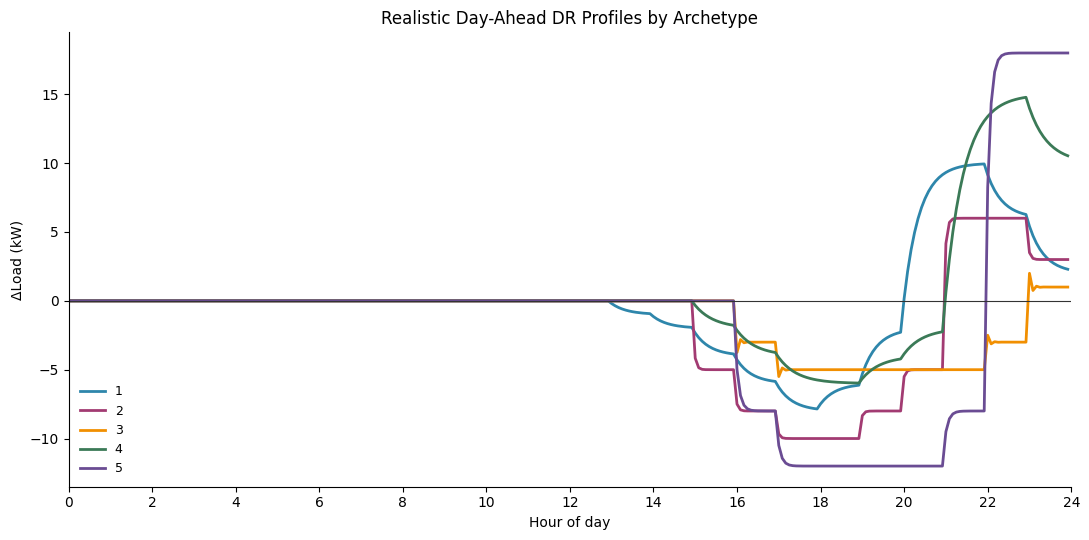

In [4]:
scheduled_profiles_DA, labels = generateDAProfiles(archetypes)

## Enumerate RT Profiles

In [5]:
T = 288

delta_raw = {
    "1":     np.array([-15, -15, +15, +15]),
    "2":    np.array([-10, -10, +20]),
    "3":     np.array([-20, -20, +30, +10]),
    "4": np.array([+5, +5, -10, -10, +5, +5]),
}

TAU_MINUTES = {
    "1":     12,
    "2":    12,
    "3":     12,
    "4": 12,
}

OP_START, OP_END = T // 2, T  


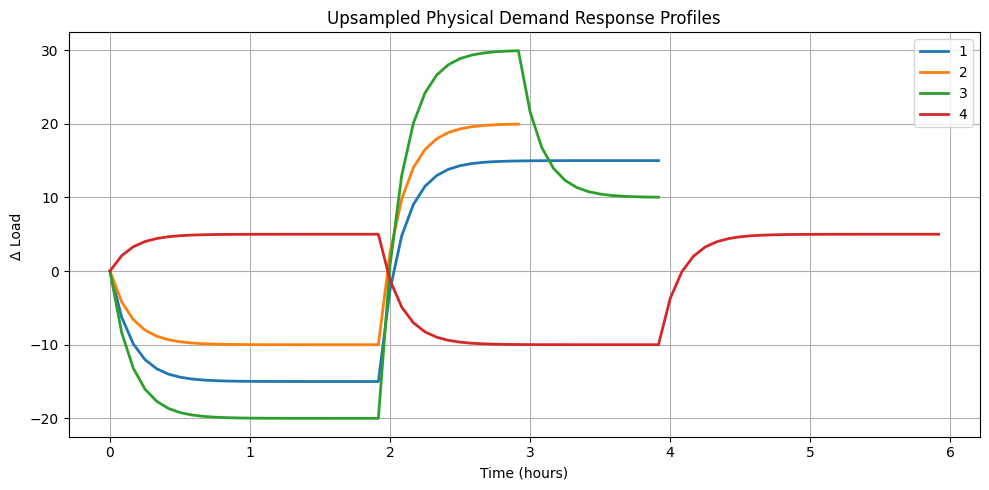

In [6]:
results = generateRTProfiles(delta_raw,
    TAU_MINUTES,
    T,
    OP_START,
    OP_END,
    intervals_per_hour=12,
    dt_minutes=5,
    start_step=3,                 
    hourly_interrupt_only=False,  
)

enumerated_profiles_RT = results["profiles"]
resource_names = results["resource_names"]
valid_i = results["valid_i"]
start_of = results["start_of"]
n_starts = results["n_starts"]

n_starts_max = max(n_starts.values())


## Scenarios 

/Users/michael/Desktop/Dissertation/fiveMinScenarioTree.py:99: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  histLoads['TimeStamp'] = pd.to_datetime(histLoads['TimeStamp'])


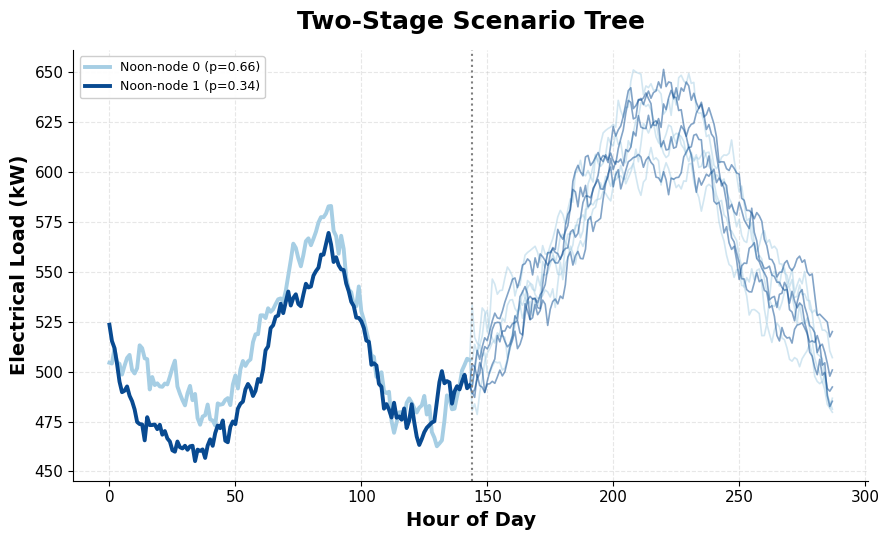

In [7]:
fullScenarios, scenarioProbs,scenarioToNode  = load_scenario_tree(n_noon_nodes, n_evening_per_node,
                        std_night,
                        n_initial=3000,
                        csv_path='Pricing data/hrl_load_metered.csv',
                        granularity = '5min',
                        target_date='2025-12-10')


## Model 

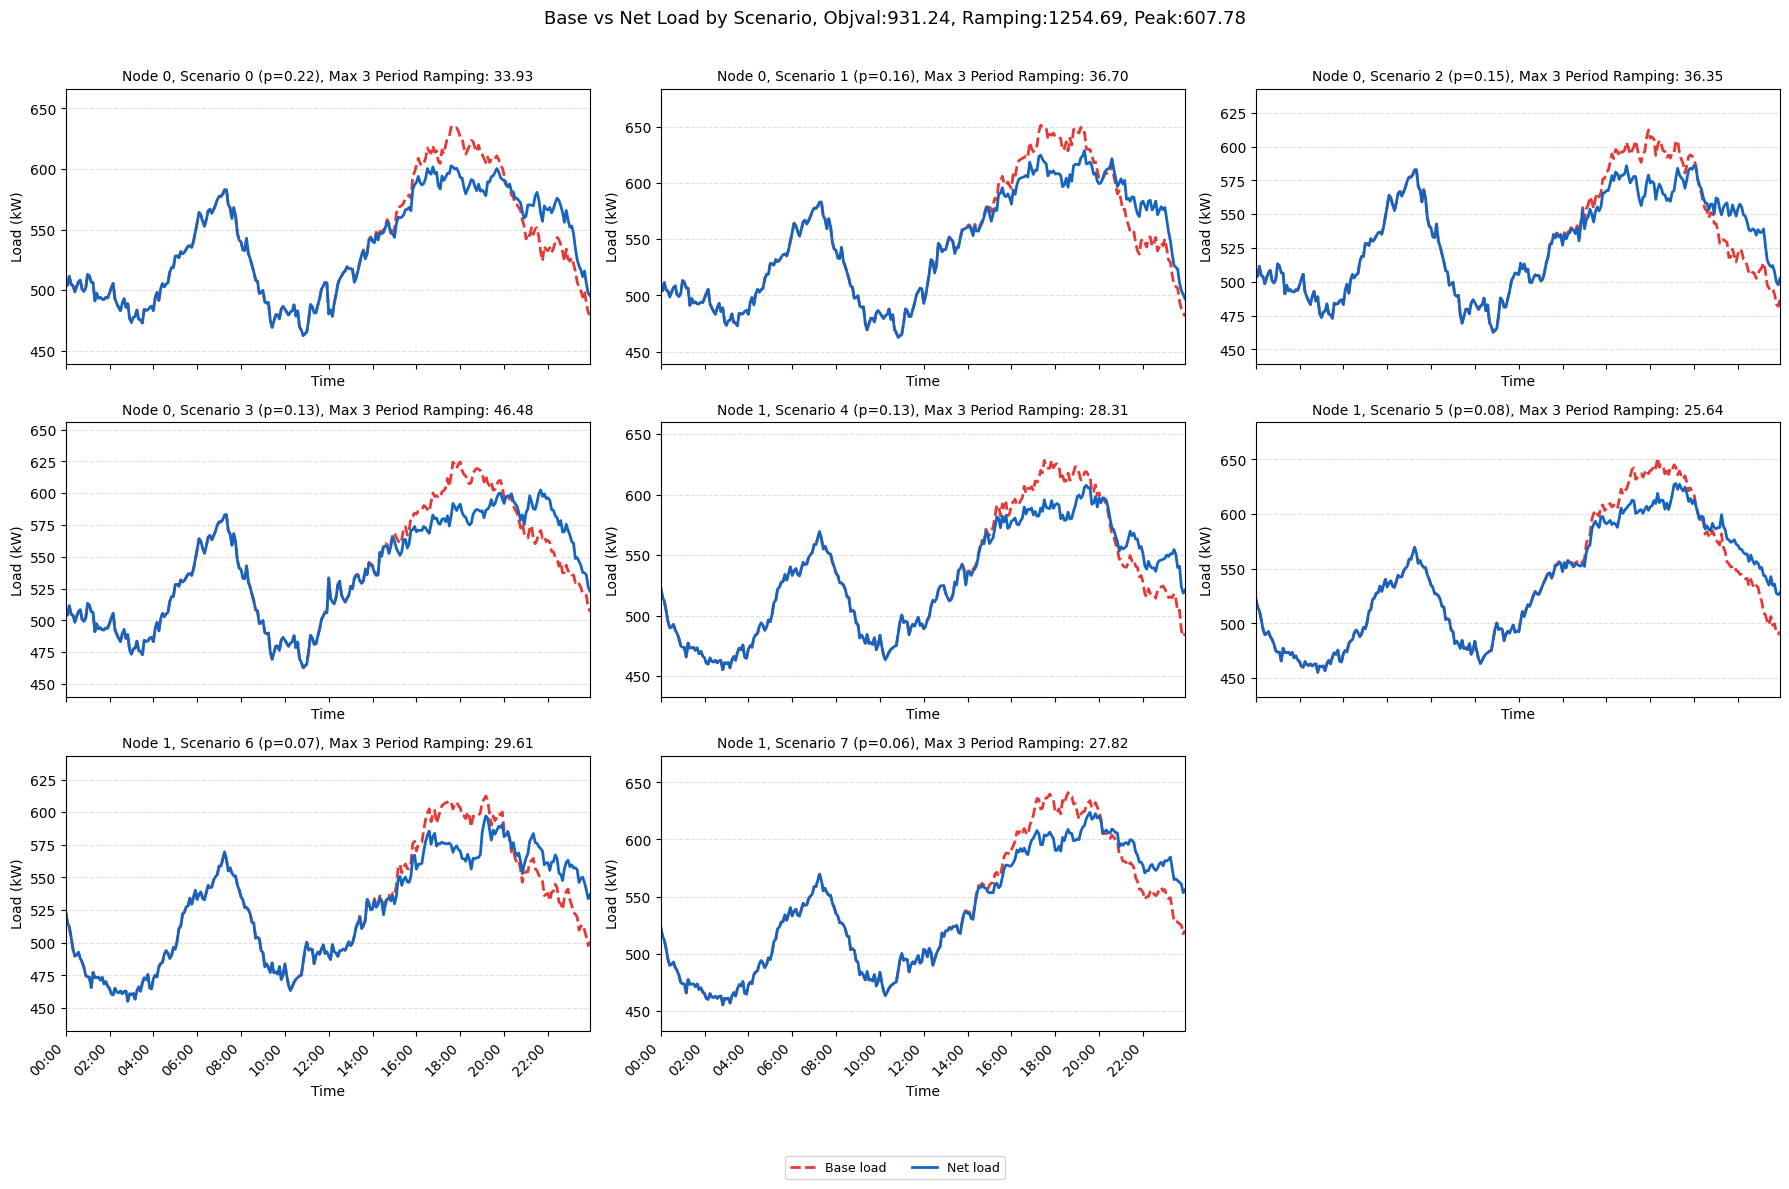

In [8]:

L_net_vals, delta_L_vals, delta_L_Fixed_vals, drModel, objval, r_vals, pi_vals, max_rolling_ramp = drMSPModel_EnumerateRT(alpha, max_rt_DR, max_da_DR,
             scheduled_profiles_DA, enumerated_profiles_RT,n_noon_nodes, n_evening_per_node, scenarioProbs, fullScenarios, scenarioToNode, rampLimit, n_starts_max)

n_scenarios = n_noon_nodes * n_evening_per_node

plotLoadprofiles(L_net_vals, delta_L_vals, delta_L_Fixed_vals, scenarioProbs, fullScenarios, n_scenarios, objval, r_vals,pi_vals, scenarioToNode, max_rolling_ramp)



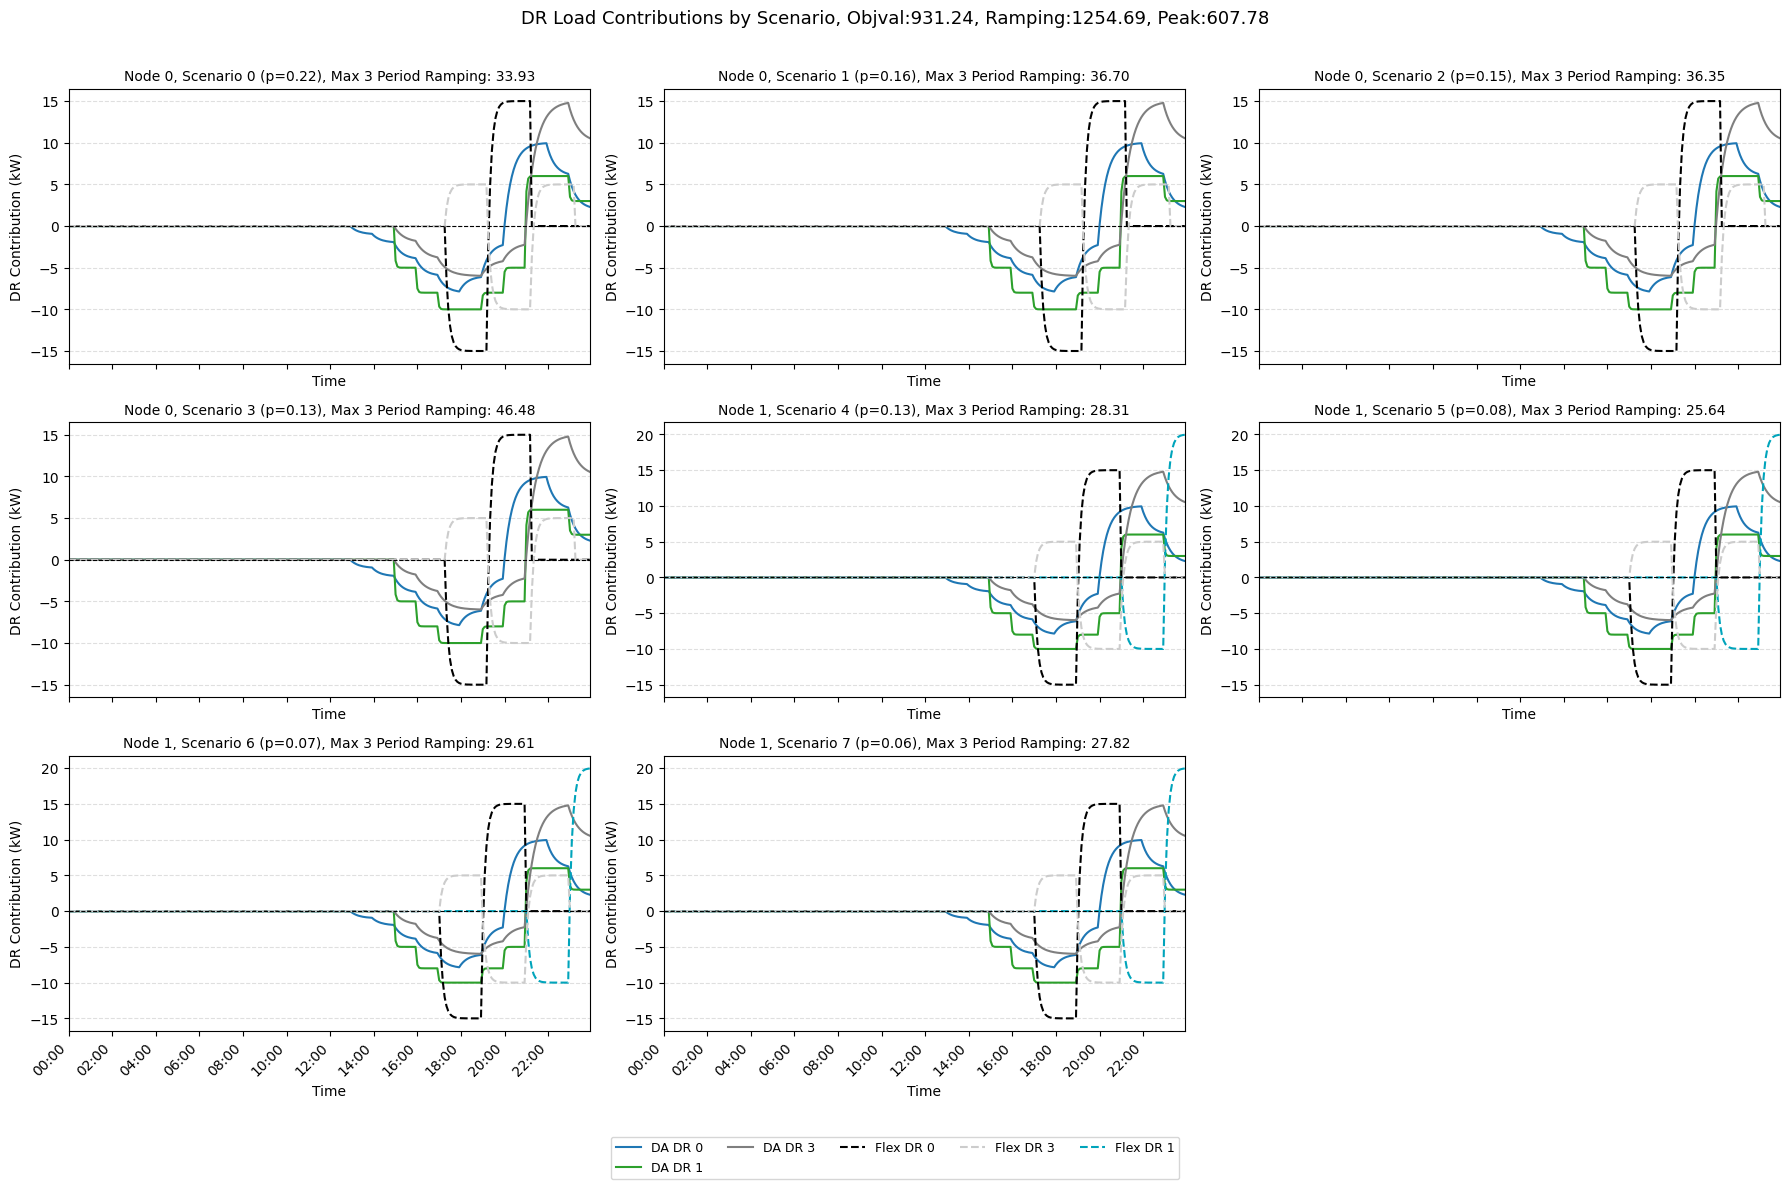

In [9]:
plotDRUsageForEnumerate(L_net_vals, delta_L_vals, delta_L_Fixed_vals, scenarioProbs, objval, r_vals,pi_vals, scenarioToNode, max_rolling_ramp)


## Limit RT DR calls to Hourly

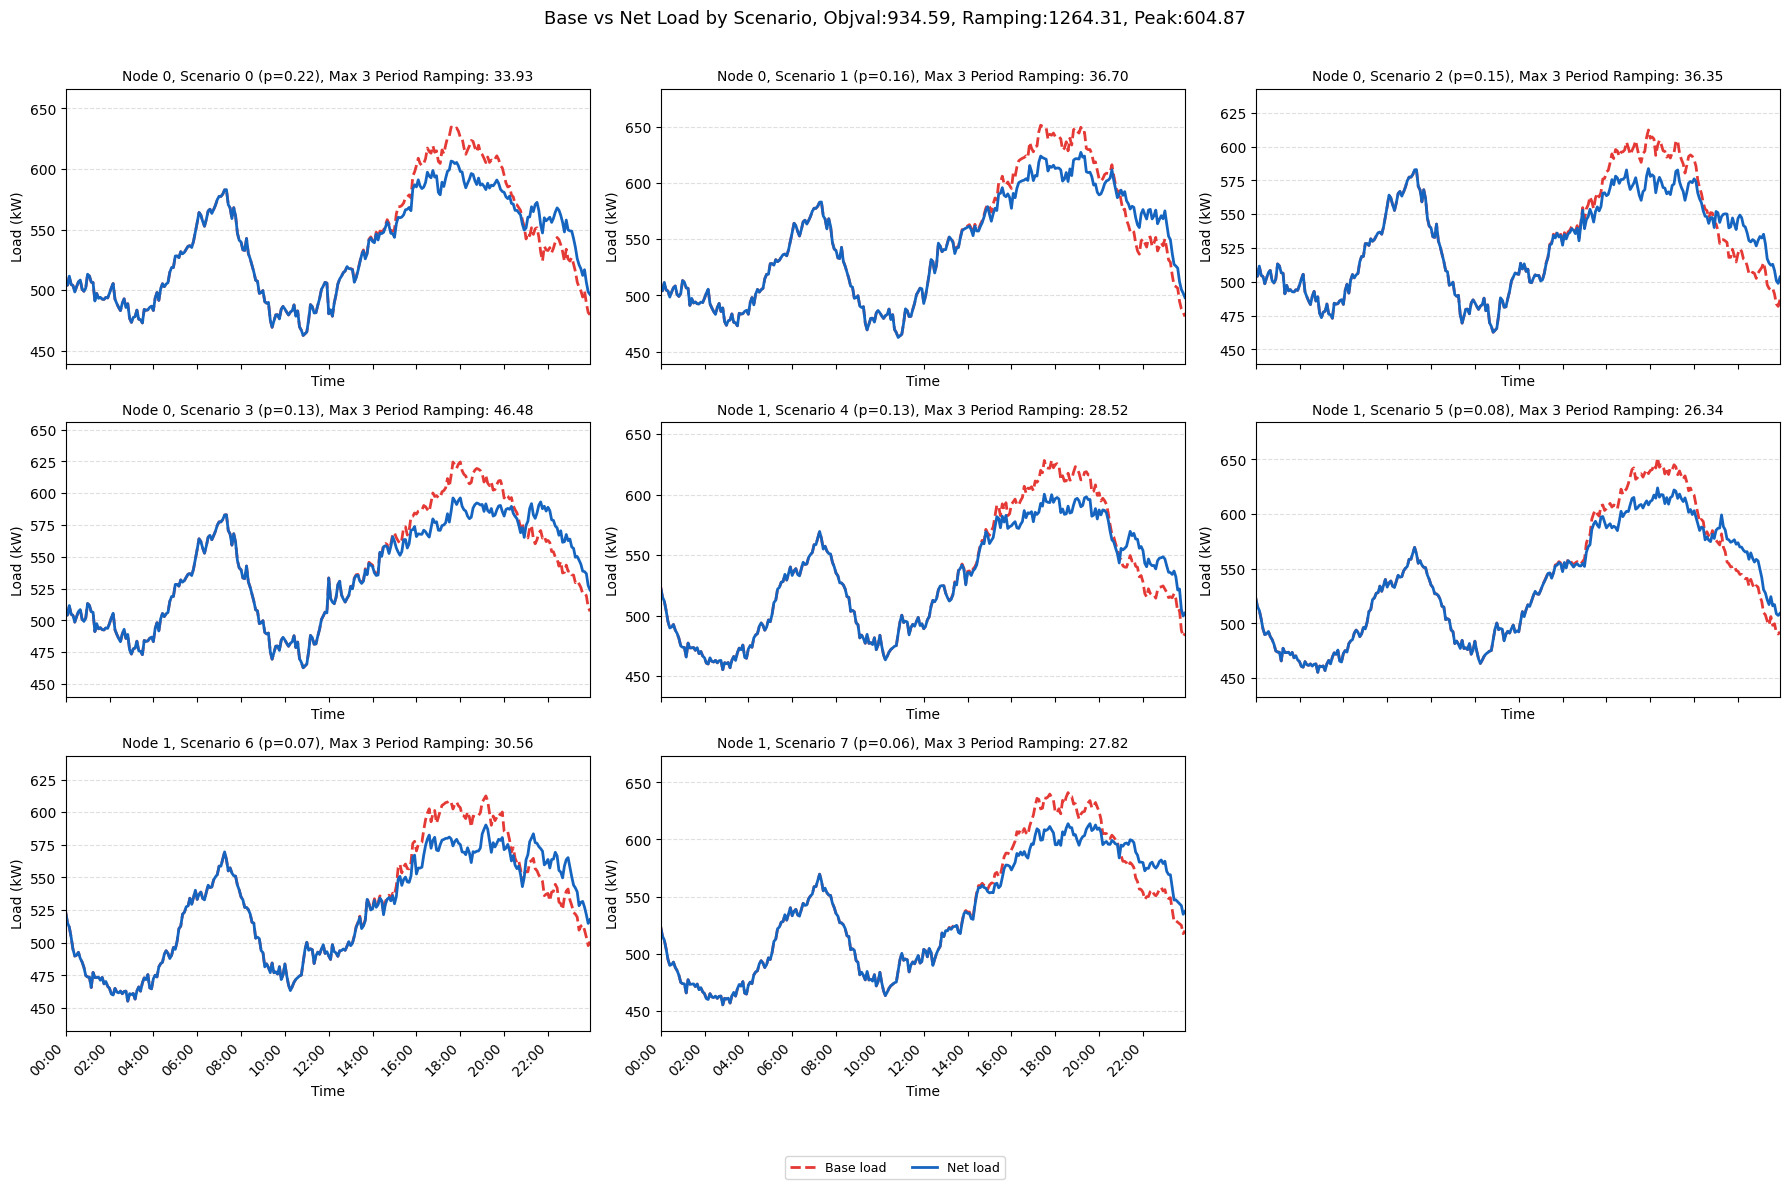

In [10]:
results = generateRTProfiles(delta_raw,
    TAU_MINUTES,
    T,
    OP_START,
    OP_END,
    intervals_per_hour=12,
    dt_minutes=5,
    start_step=3,                 
    hourly_interrupt_only=True, 
    showPlot = False                                      
)

enumerated_profiles_RT = results["profiles"]
resource_names = results["resource_names"]
valid_i = results["valid_i"]
start_of = results["start_of"]
n_starts = results["n_starts"]

n_starts_max = max(n_starts.values())

L_net_vals, delta_L_vals, delta_L_Fixed_vals, drModel, objval, r_vals, pi_vals, max_rolling_ramp = drMSPModel_EnumerateRT(alpha, max_rt_DR, max_da_DR,
             scheduled_profiles_DA, enumerated_profiles_RT,n_noon_nodes, n_evening_per_node, scenarioProbs, fullScenarios, scenarioToNode, rampLimit, n_starts_max)

n_scenarios = n_noon_nodes * n_evening_per_node

plotLoadprofiles(L_net_vals, delta_L_vals, delta_L_Fixed_vals, scenarioProbs, fullScenarios, n_scenarios, objval, r_vals,pi_vals, scenarioToNode, max_rolling_ramp)


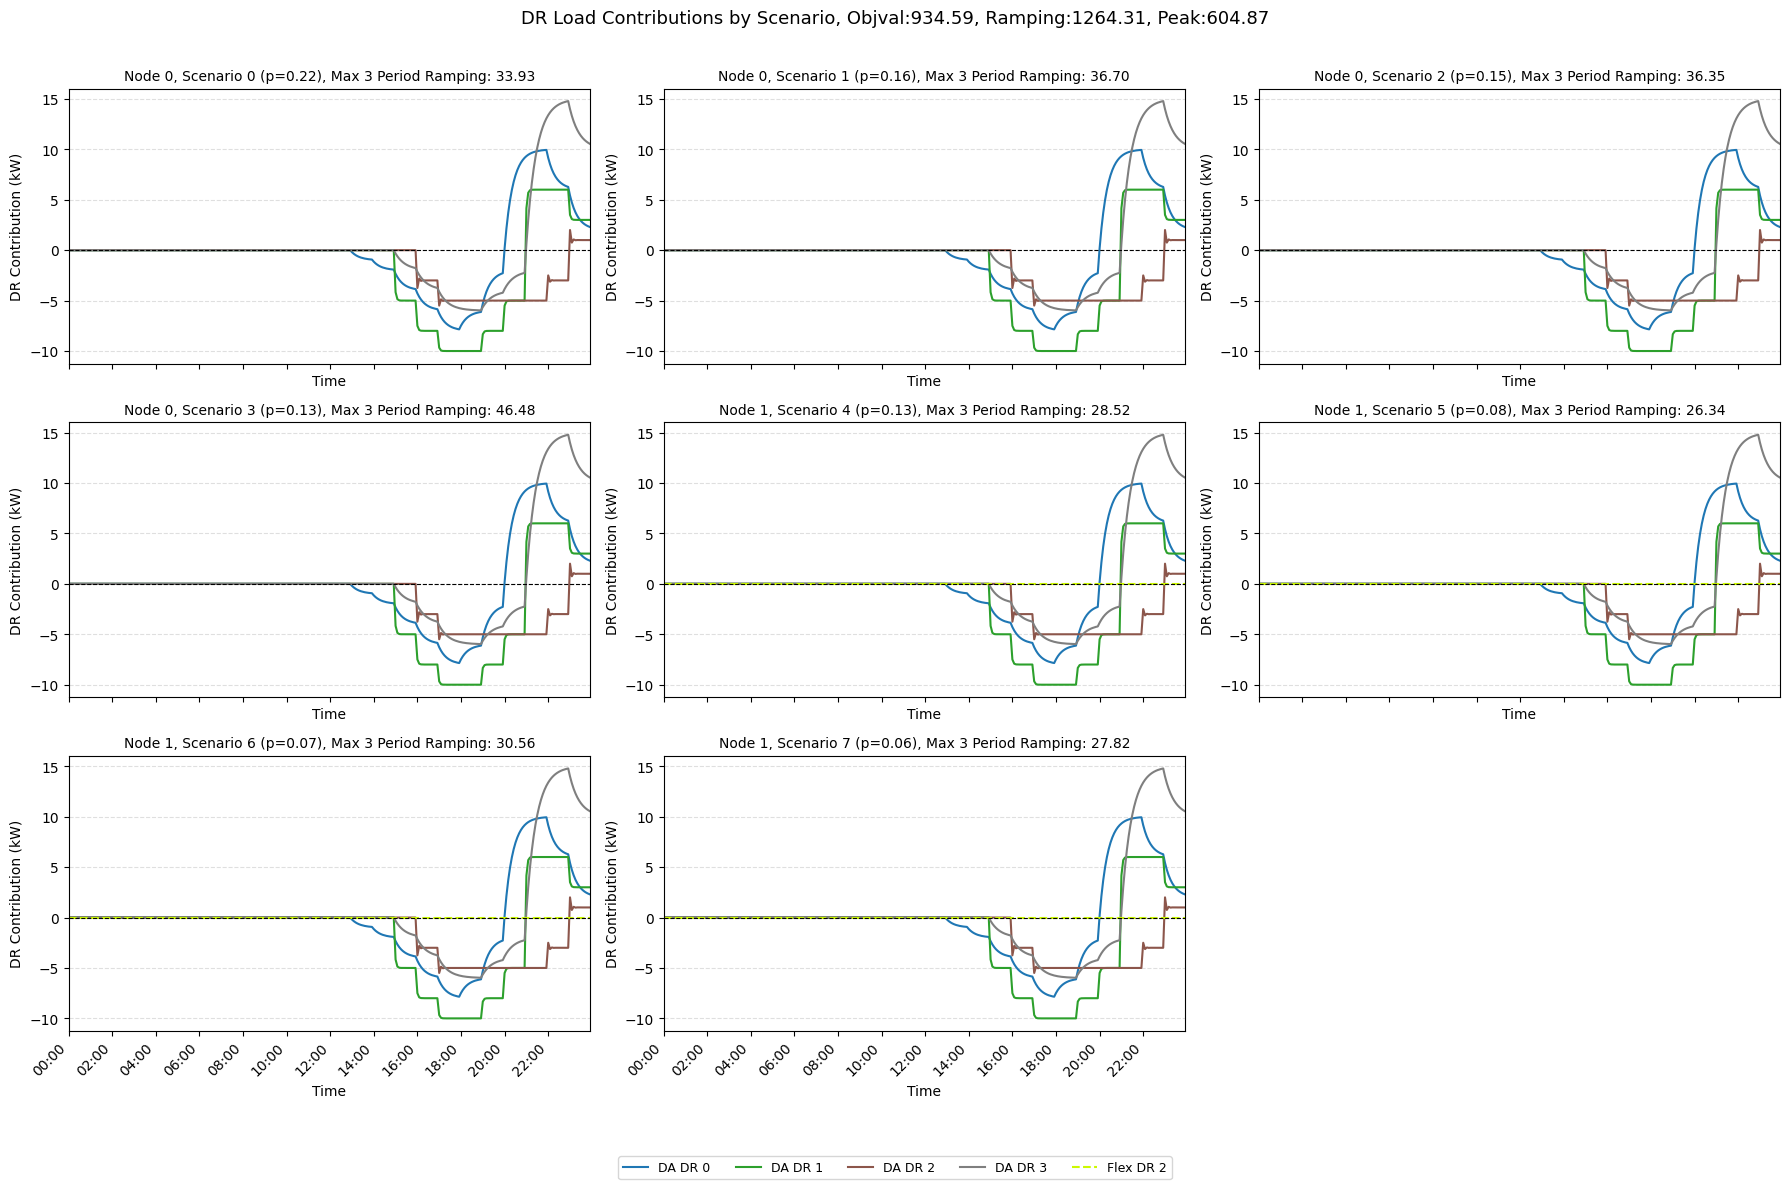

In [11]:
plotDRUsageForEnumerate(L_net_vals, delta_L_vals, delta_L_Fixed_vals, scenarioProbs, objval, r_vals,pi_vals, scenarioToNode, max_rolling_ramp)


## Scenario Analysis 

In [17]:
results = generateRTProfiles(delta_raw,
    TAU_MINUTES,
    T,
    OP_START,
    OP_END,
    intervals_per_hour=12,
    dt_minutes=5,
    start_step=3,                 
    hourly_interrupt_only=False, 
    showPlot = False
)

enumerated_profiles_RT = results["profiles"]
resource_names = results["resource_names"]
valid_i = results["valid_i"]
start_of = results["start_of"]
n_starts = results["n_starts"]

n_starts_max = max(n_starts.values())

n_noon_nodes = 2
n_evening_per_node = 2

fullScenarios, scenarioProbs,scenarioToNode  = load_scenario_tree(n_noon_nodes, n_evening_per_node,
                        std_night,
                        n_initial=3000,
                        csv_path='Pricing data/hrl_load_metered.csv',
                        granularity = '5min',
                        target_date='2025-12-10',
                        showPlot = False)



rampvalues = np.arange(30, 40, 2)


objVals = np.zeros(len(rampvalues))
peakVals = np.zeros(len(rampvalues))
rampVals =  np.zeros(len(rampvalues))

for i, rampValue in enumerate(rampvalues):
        try:
            L_net_vals, delta_L_vals, delta_L_Fixed_vals, drModel, objval, r_vals, pi_vals, max_rolling_ramp = drMSPModel_EnumerateRT(alpha, max_rt_DR, max_da_DR,
                    scheduled_profiles_DA, enumerated_profiles_RT,n_noon_nodes, n_evening_per_node, scenarioProbs, fullScenarios, scenarioToNode, rampValue, n_starts_max)
            objVals[i] = objval
            S = sorted(set(s for s, t in L_net_vals.keys()))
            T = sorted(set(t for s, t in L_net_vals.keys()))
        
            rampVals[i] = sum(scenarioProbs[s] * sum(r_vals[s, t] for t in T) for s in S)
            peakVals[i] = sum(scenarioProbs[s] * pi_vals[s] for s in S)   
        except:
            objVals[i] = 0 
            rampVals[i] = 0
            peakVals[i] = 0   
            

      

/Users/michael/Desktop/Dissertation/fiveMinScenarioTree.py:99: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  histLoads['TimeStamp'] = pd.to_datetime(histLoads['TimeStamp'])


In [18]:
print(objVals)
print(rampVals)
print(peakVals)

[  0.          0.        925.5590314 925.5590314 925.5590314]
[   0.            0.         1242.91397766 1242.91397766 1242.91397766]
[  0.           0.         608.20408513 608.20408513 608.20408513]
